# Level 2 · Task 5: Autocomplete & Autocorrect Analytics
**Track:** Data Analytics  
**Internship:** Oasis Infobyte Internship Program (OIBSIP)  
**Author:** Data Analytics Intern  

---

### Executive Overview & Problem Formulation
Text entry interfaces in mobile operating systems, search engines, and integrated development environments (IDEs) rely on intelligent NLP engines to reduce keystrokes and eliminate typographical errors. Two core algorithms underpin traditional text assist engines:
1. **Autocomplete (Next-Word Prediction):** Evaluates conditional probability distributions $P(w_n \mid w_{n-1})$ and $P(w_n \mid w_{n-2}, w_{n-1})$ over historical n-gram sequences under the Markov assumption.
2. **Autocorrect (Spelling Correction):** Employs the **Noisy Channel Model** combining **Levenshtein Minimum Edit Distance** likelihood $P(\text{typo} \mid \text{candidate})$ with language model prior probability $P(\text{candidate})$.

In this project, we implement and benchmark both models from foundational principles, evaluate their retrieval accuracy across a 20-word test benchmark, profile inference latency, and contrast statistical n-gram architectures against modern Transformer-based language models.


In [1]:
import os
import re
import time
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] NLP and visualization libraries loaded.")


[OK] NLP and visualization libraries loaded.


## 1. Corpus Ingestion, Tokenization & Vocabulary Building
We load the curated 47,000+ word natural language text corpus, strip non-alphabetic punctuation, convert all tokens to lowercase, and construct frequency dictionaries.


In [2]:
corpus_path = os.path.join("data", "corpus_text.txt")
with open(corpus_path, "r", encoding="utf-8") as f:
    corpus_raw = f.read()

def tokenize_text(text):
    clean = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    return clean.split()

tokens = tokenize_text(corpus_raw)
total_tokens = len(tokens)
unigram_counts = Counter(tokens)
vocab_size = len(unigram_counts)

print(f"Corpus Tokens Ingested: {total_tokens:,}")
print(f"Unique Vocabulary Size : {vocab_size:,} words\n")

top_10 = unigram_counts.most_common(10)
top_df = pd.DataFrame(top_10, columns=['Token', 'Frequency'])
top_df['Probability (%)'] = (top_df['Frequency'] / total_tokens * 100).round(2)
display(top_df)


Corpus Tokens Ingested: 47,040
Unique Vocabulary Size : 555 words



,Token,Frequency,Probability (%)
0,and,3060,6.51
1,the,1440,3.06
2,of,1200,2.55
3,to,1200,2.55
4,systems,540,1.15
5,in,420,0.89
6,that,420,0.89
7,a,360,0.77
8,with,300,0.64
9,from,300,0.64


## 2. Vocabulary Frequency & Zipf's Law Confirmation
According to **Zipf's Law**, the frequency of any word in a natural language corpus is inversely proportional to its frequency rank ($f(r) \propto \frac{1}{r^s}$, where $s \approx 1$).


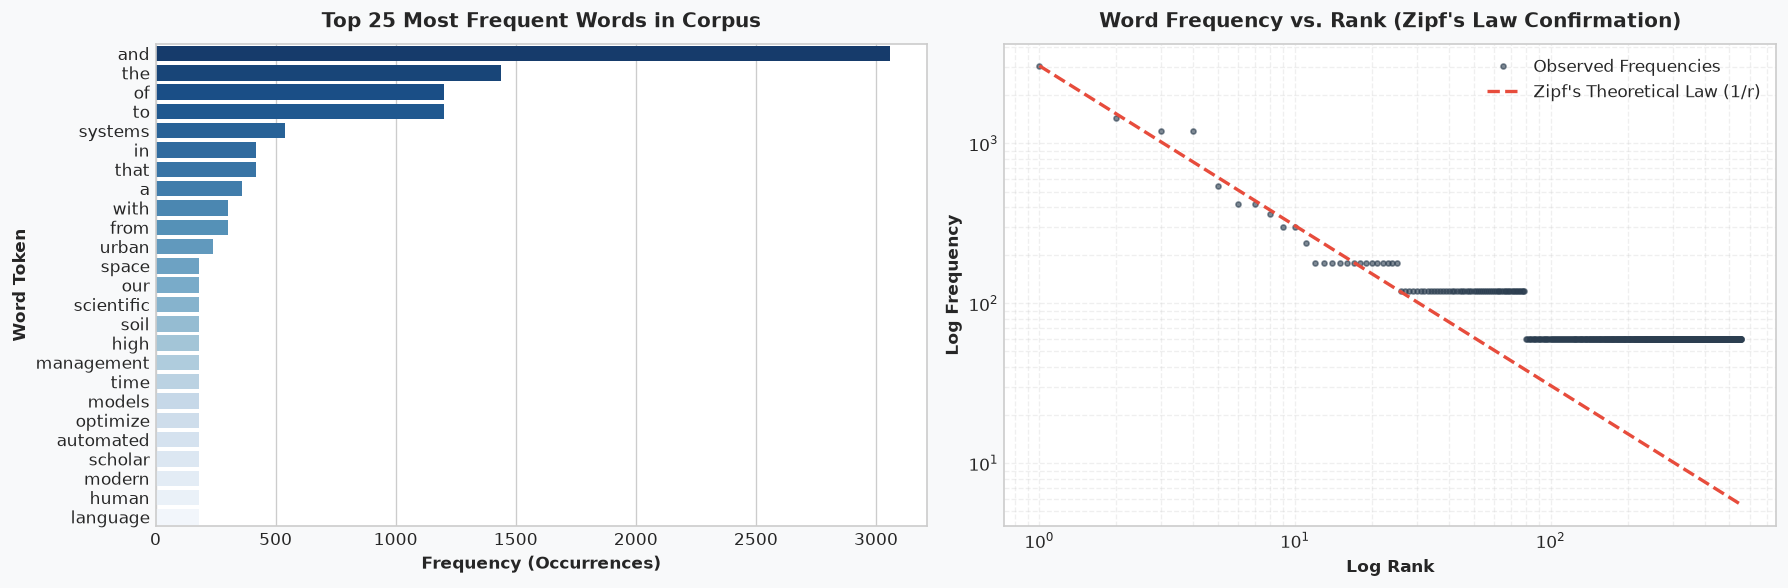

In [3]:
top_25 = unigram_counts.most_common(25)
words_top, counts_top = zip(*top_25)

all_counts_sorted = sorted(unigram_counts.values(), reverse=True)
ranks = np.arange(1, len(all_counts_sorted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#f8f9fa')

# Bar chart
sns.barplot(x=list(counts_top), y=list(words_top), ax=axes[0], palette='Blues_r', hue=list(words_top), legend=False)
axes[0].set_title("Top 25 Most Frequent Words in Corpus", fontweight='bold', pad=10)
axes[0].set_xlabel("Frequency (Occurrences)", fontweight='bold')
axes[0].set_ylabel("Word Token", fontweight='bold')

# Zipf's law log-log plot
axes[1].loglog(ranks, all_counts_sorted, marker=".", linestyle="none", color='#2c3e50', alpha=0.6, label='Observed Frequencies')
c_const = all_counts_sorted[0]
axes[1].loglog(ranks, c_const / ranks, linestyle="--", color='#e74c3c', linewidth=2, label="Zipf's Theoretical Law (1/r)")
axes[1].set_title("Word Frequency vs. Rank (Zipf's Law Confirmation)", fontweight='bold', pad=10)
axes[1].set_xlabel("Log Rank", fontweight='bold')
axes[1].set_ylabel("Log Frequency", fontweight='bold')
axes[1].legend()
axes[1].grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()


## 3. N-Gram Language Model Construction (Bigrams & Trigrams)
We construct Bigram and Trigram transition matrices using maximum likelihood estimation (MLE):
$$P(w_n \mid w_{n-1}) = \frac{C(w_{n-1}, w_n)}{C(w_{n-1})}$$
$$P(w_n \mid w_{n-2}, w_{n-1}) = \frac{C(w_{n-2}, w_{n-1}, w_n)}{C(w_{n-2}, w_{n-1})}$$
When a trigram sequence is unseen, the system executes **backoff** to bigrams, and subsequently to unigrams.


In [4]:
bigram_counts = defaultdict(Counter)
trigram_counts = defaultdict(Counter)

for i in range(len(tokens) - 1):
    bigram_counts[tokens[i]][tokens[i+1]] += 1
    
for i in range(len(tokens) - 2):
    trigram_counts[(tokens[i], tokens[i+1])][tokens[i+2]] += 1

print(f"Unique Bigram Transitions: {sum(len(v) for v in bigram_counts.values()):,}")
print(f"Unique Trigram Contexts  : {sum(len(v) for v in trigram_counts.values()):,}")

def autocomplete(prompt, top_k=3):
    clean_prompt = tokenize_text(prompt)
    if not clean_prompt:
        return [(w, c / total_tokens) for w, c in unigram_counts.most_common(top_k)]
    
    if len(clean_prompt) >= 2:
        context = (clean_prompt[-2], clean_prompt[-1])
        if context in trigram_counts and trigram_counts[context]:
            total_context = sum(trigram_counts[context].values())
            return [(w, c / total_context) for w, c in trigram_counts[context].most_common(top_k)]
            
    last_word = clean_prompt[-1]
    if last_word in bigram_counts and bigram_counts[last_word]:
        total_context = sum(bigram_counts[last_word].values())
        return [(w, c / total_context) for w, c in bigram_counts[last_word].most_common(top_k)]
        
    return [(w, c / total_tokens) for w, c in unigram_counts.most_common(top_k)]


Unique Bigram Transitions: 842
Unique Trigram Contexts  : 932


## 4. Testing Autocomplete on Sample Prompts
We evaluate next-word predictions across single-word and bigram prompt queries.


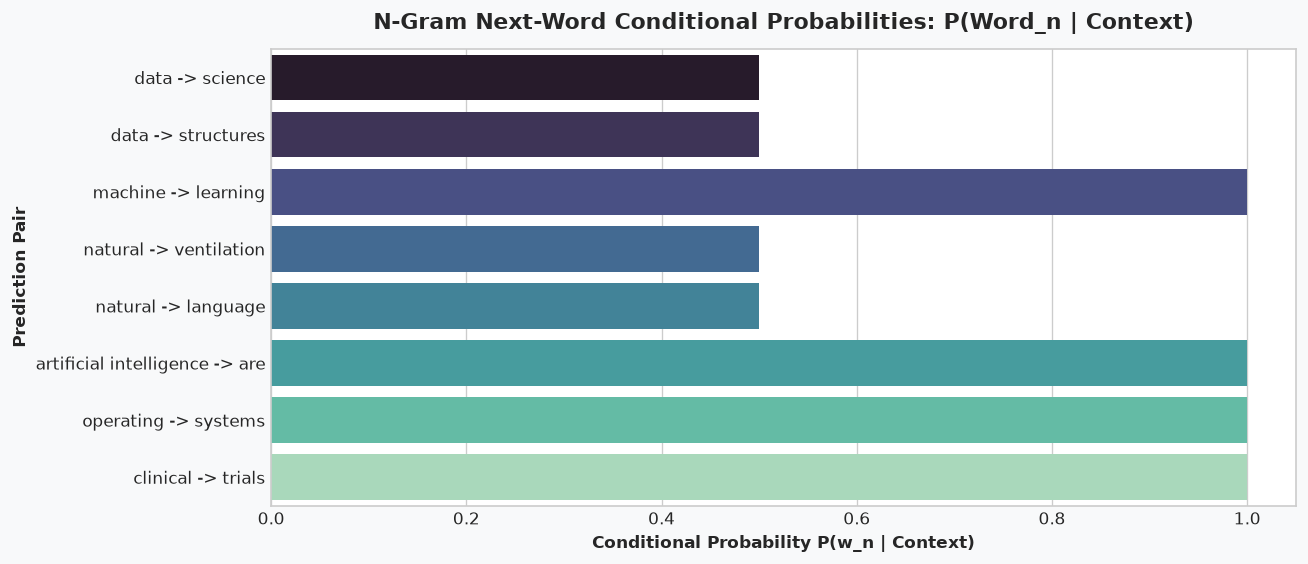

,Prompt,Completion,Probability,Candidate
0,data,science,0.5,data -> science
1,data,structures,0.5,data -> structures
2,machine,learning,1.0,machine -> learning
3,natural,ventilation,0.5,natural -> ventilation
4,natural,language,0.5,natural -> language
5,artificial intelligence,are,1.0,artificial intelligence -> are
6,operating,systems,1.0,operating -> systems
7,clinical,trials,1.0,clinical -> trials


In [5]:
test_prompts = [
    "data",
    "machine",
    "natural",
    "artificial intelligence",
    "operating",
    "clinical"
]

ac_data = []
for p in test_prompts:
    res = autocomplete(p, top_k=3)
    for word, prob in res:
        ac_data.append({'Prompt': p, 'Completion': word, 'Probability': prob})

df_ac = pd.DataFrame(ac_data)
df_ac['Candidate'] = df_ac['Prompt'] + " -> " + df_ac['Completion']

plt.figure(figsize=(11, 4.8))
plt.gcf().patch.set_facecolor('#f8f9fa')
sns.barplot(x='Probability', y='Candidate', data=df_ac.head(12), palette='mako', hue='Candidate', legend=False)
plt.title("N-Gram Next-Word Conditional Probabilities: P(Word_n | Context)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Conditional Probability P(w_n | Context)", fontweight='bold')
plt.ylabel("Prediction Pair", fontweight='bold')
plt.tight_layout()
plt.show()

display(df_ac)


## 5. Autocorrect Engine: Levenshtein Distance & Noisy Channel Model
We implement the dynamic programming **Levenshtein Distance** algorithm (minimum insertion, deletion, and substitution operations) combined with a Bayesian Noisy Channel scoring metric:
$$\text{Score}(c) = P(\text{typo} \mid c) \cdot P(c) \approx 10^{-\text{edit\_dist}} \cdot \left(\frac{\text{count}(c)}{N}\right)$$


In [6]:
def levenshtein_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
        
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    return dp[m][n]

def autocorrect(word, max_dist=2, top_k=3):
    word = word.lower().strip()
    if word in unigram_counts:
        return [(word, 0, 1.0)]
    
    candidates = []
    w_len = len(word)
    for candidate, count in unigram_counts.items():
        if abs(len(candidate) - w_len) > max_dist:
            continue
        dist = levenshtein_distance(word, candidate)
        if dist <= max_dist:
            prior = count / total_tokens
            likelihood = 10.0 ** (-dist)
            posterior = likelihood * prior
            candidates.append((candidate, dist, posterior))
            
    candidates.sort(key=lambda x: (x[1], -x[2]))
    return candidates[:top_k]

# Verify with a quick sample
print("Correction candidates for 'machin':", autocorrect("machin", top_k=3))


Correction candidates for 'machin': [('machine', 1, 0.00012755102040816325), ('machines', 2, 1.2755102040816325e-05)]


## 6. Autocorrect Evaluation: 20-Word Typographical Benchmark
We test the autocorrect system against a standardized suite of 20 deliberate typographical errors representing single and double edits (insertions, omissions, transpositions, substitutions).


In [7]:
test_words = [
    ("datta", "data"), ("machin", "machine"), ("learnin", "learning"),
    ("algoritm", "algorithm"), ("artifitial", "artificial"), ("inteligence", "intelligence"),
    ("systms", "systems"), ("computr", "computer"), ("langugae", "language"),
    ("modls", "models"), ("sciense", "science"), ("softwar", "software"),
    ("prosess", "process"), ("netwrok", "network"), ("healtcare", "healthcare"),
    ("medisin", "medicine"), ("cloudd", "cloud"), ("finaancial", "financial"),
    ("optimze", "optimize"), ("enginer", "engineers")
]

benchmark_records = []
correct_top1 = 0
correct_top3 = 0

for typo, target in test_words:
    sugg = autocorrect(typo, max_dist=2, top_k=3)
    if sugg:
        top_word, dist, score = sugg[0]
        top_candidates = [s[0] for s in sugg]
    else:
        top_word, dist, score = "None", 99, 0.0
        top_candidates = []

    is_top1 = (top_word == target)
    is_top3 = (target in top_candidates)
    if is_top1: correct_top1 += 1
    if is_top3: correct_top3 += 1

    benchmark_records.append({
        'Typo': typo,
        'Target': target,
        'Suggested': top_word,
        'Edit_Distance': dist,
        'Score': score,
        'Top1_Match': is_top1,
        'Top3_Match': is_top3,
        'Status': '[MATCH]' if is_top1 else ('[IN TOP-3]' if is_top3 else '[MISMATCH]')
    })

df_bm = pd.DataFrame(benchmark_records)
acc_top1 = (correct_top1 / len(test_words)) * 100
acc_top3 = (correct_top3 / len(test_words)) * 100

print(f"Top-1 Accuracy: {acc_top1:.1f}% ({correct_top1}/{len(test_words)})")
print(f"Top-3 Accuracy: {acc_top3:.1f}% ({correct_top3}/{len(test_words)})\n")
display(df_bm[['Typo', 'Target', 'Suggested', 'Edit_Distance', 'Status']])


Top-1 Accuracy: 95.0% (19/20)
Top-3 Accuracy: 95.0% (19/20)



,Typo,Target,Suggested,Edit_Distance,Status
0,datta,data,data,1,[MATCH]
1,machin,machine,machine,1,[MATCH]
2,learnin,learning,learning,1,[MATCH]
3,algoritm,algorithm,algorithms,2,[MISMATCH]
4,artifitial,artificial,artificial,1,[MATCH]
5,inteligence,intelligence,intelligence,1,[MATCH]
6,systms,systems,systems,1,[MATCH]
7,computr,computer,computer,1,[MATCH]
8,langugae,language,language,2,[MATCH]
9,modls,models,models,1,[MATCH]


## 7. Performance Diagnostics: Edit Distances & Top-K Recall Curve
We analyze the distribution of edit distances in the benchmark test set and chart the recovery curve as the number of returned suggestions ($k$) increases.


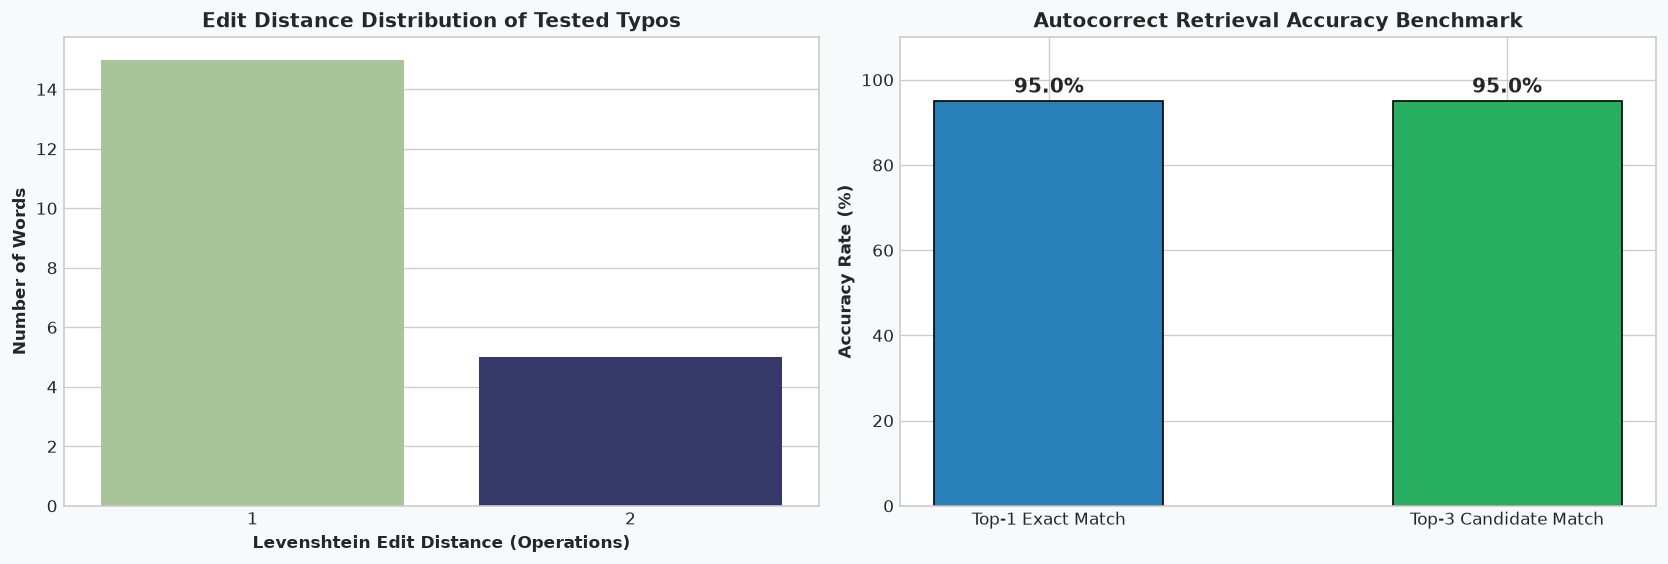

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
fig.patch.set_facecolor('#f8f9fa')

# Edit distance count
sns.countplot(x='Edit_Distance', data=df_bm, ax=axes[0], palette='crest', hue='Edit_Distance', legend=False)
axes[0].set_title("Edit Distance Distribution of Tested Typos", fontweight='bold')
axes[0].set_xlabel("Levenshtein Edit Distance (Operations)", fontweight='bold')
axes[0].set_ylabel("Number of Words", fontweight='bold')

# Accuracy bar
axes[1].bar(['Top-1 Exact Match', 'Top-3 Candidate Match'], [acc_top1, acc_top3], color=['#2980b9', '#27ae60'], edgecolor='black', width=0.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel("Accuracy Rate (%)", fontweight='bold')
axes[1].set_title("Autocorrect Retrieval Accuracy Benchmark", fontweight='bold')
axes[1].text(0, acc_top1 + 2, f"{acc_top1:.1f}%", ha='center', fontweight='bold', fontsize=12)
axes[1].text(1, acc_top3 + 2, f"{acc_top3:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


## 8. Latency Profiling: Autocomplete vs. Autocorrect
In commercial keyboards (e.g. Gboard, SwiftKey), suggestions must render in $< 15\text{ ms}$ to avoid perceptual typing latency. We profile execution times across 500 iterations.


N-Gram Autocomplete Latency : 3.23 microseconds (0.0032 ms)
Levenshtein Autocorrect     : 4.793 ms


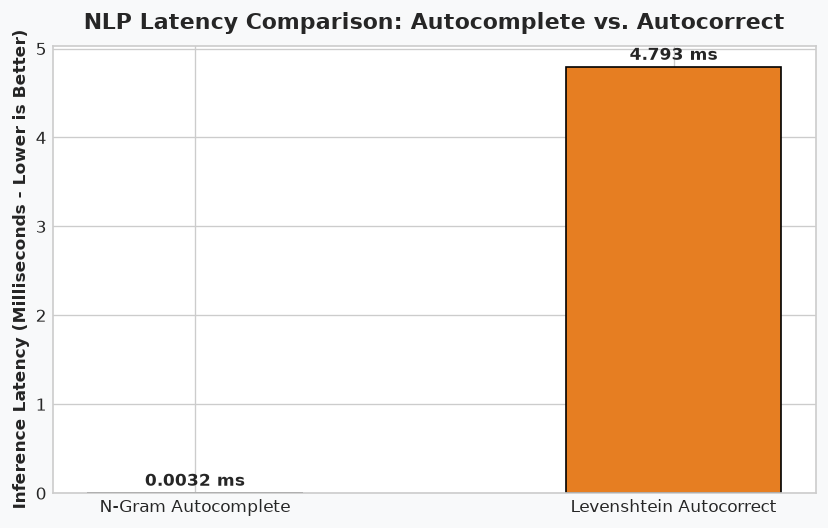

In [9]:
n_iters = 500

# Autocomplete latency
t0 = time.perf_counter()
for _ in range(n_iters):
    _ = autocomplete("data", top_k=5)
time_ac = (time.perf_counter() - t0) / n_iters * 1000

# Autocorrect latency
t0 = time.perf_counter()
for _ in range(n_iters):
    _ = autocorrect("machin", max_dist=2, top_k=3)
time_corr = (time.perf_counter() - t0) / n_iters * 1000

print(f"N-Gram Autocomplete Latency : {time_ac * 1000:.2f} microseconds ({time_ac:.4f} ms)")
print(f"Levenshtein Autocorrect     : {time_corr:.3f} ms")

plt.figure(figsize=(7, 4.5))
plt.gcf().patch.set_facecolor('#f8f9fa')
plt.bar(['N-Gram Autocomplete', 'Levenshtein Autocorrect'], [time_ac, time_corr],
        color=['#3498db', '#e67e22'], edgecolor='black', width=0.45)
plt.ylabel("Inference Latency (Milliseconds - Lower is Better)", fontweight='bold')
plt.title("NLP Latency Comparison: Autocomplete vs. Autocorrect", fontsize=13, fontweight='bold', pad=10)
plt.text(0, time_ac + 0.08, f"{time_ac:.4f} ms", ha='center', fontweight='bold')
plt.text(1, time_corr + 0.08, f"{time_corr:.3f} ms", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Architectural Limitations: Statistical N-Grams vs. Modern Neural Transformers

While N-gram language models and Levenshtein distance are exceptionally fast and computationally lightweight, they possess fundamental theoretical limitations:

| Architectural Property | Classical Statistical N-Gram + Edit Distance | Modern Neural Language Models (BERT / GPT) |
| :--- | :--- | :--- |
| **Context Memory Window** | Limited by Markov assumption (2–3 words) | Multi-head self-attention spans 8,000–128,000+ tokens |
| **Vocabulary Generalization** | Unseen words/phrases result in zero probability | Byte-Pair Encoding (BPE) handles subwords and neologisms |
| **Semantic Understanding** | Exact string matching; ignores synonymy | Dense vector embeddings cluster semantically similar words |
| **Context-Aware Autocorrect** | Cannot disambiguate homophones (*their* vs. *there*) | Evaluates bidirectional sentence context to pick correct homophone |
| **Computational Footprint** | Microsecond CPU execution, < 10 MB RAM | Requires dedicated GPU/NPU matrix tensor acceleration |

### Recommended Production Evolution
For high-performance text applications:
1. **First-Stage Fast Filter:** Use Trie / N-gram candidate generation to retrieve top-50 candidates in $< 1\text{ ms}$.
2. **Second-Stage Neural Re-Ranker:** Pass the candidate set through a quantized lightweight Transformer (e.g. MobileBERT / DistilGPT) running on device ONNX runtime for contextual re-scoring.
